In [4]:
import pandas as pd
import numpy as np
from matplotlib import pylab as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Задание 1.

Поработайте с датасетом про цены мобильных телефонов, обучите регрессию.

In [158]:
data = pd.read_csv('Cellphone.csv')
data.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


<Axes: >

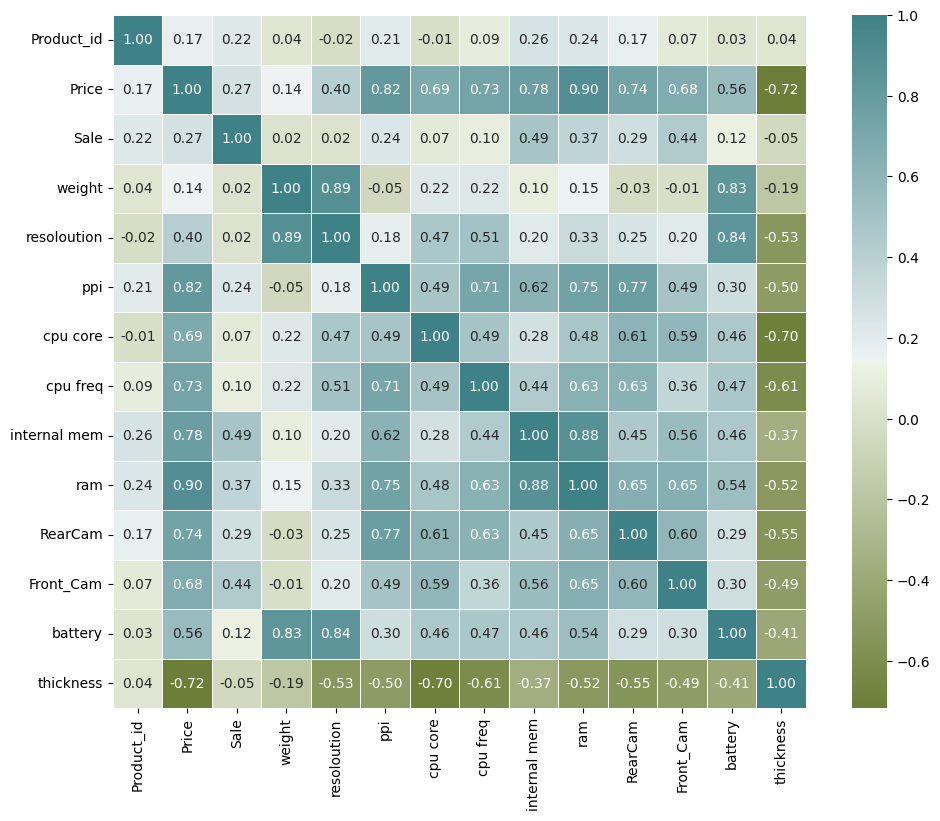

In [7]:
import seaborn as sns

plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [159]:
# роляют почти все признаки. попробуем оба варианта - и с удалением наименьших, и с их сохранением. посмотрим, что будет лучше
# линейная регрессия без масштабирования
X = data.drop('Price', axis=1)

y = data['Price']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

model = LinearRegression()
model.fit(Xtrain, ytrain)
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

print('Scores:', r2_score(ytrain, pred_train), r2_score(ytest, pred_test), mean_squared_error(pred_test, ytest) ** 0.5, mean_squared_error(pred_train, ytrain) ** 0.5)
# 0.94 - шикарно! удалять признаки смысла не вижу - их немного и модель работает отлично

Scores: 0.9522767204892084 0.9436339582502 214.62409194063562 157.55109138473497


In [160]:
# линейная регрессия с масштабированием
scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred_train), r2_score(ytest, ypred_test), mean_squared_error(ypred_test, ytest) ** 0.5, mean_squared_error(ypred_train, ytrain) ** 0.5)
# результат не изменился - модель оказалась не чувствительна к разбросу

Scores: 0.9522767204892085 0.9436339582501975 214.6240919406403 157.55109138473495


In [161]:
# теперь с L1 регуляризацией
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2_test = regressor2.predict(Xtest)
ypred2_train = regressor2.predict(Xtrain)

print('Scores:', r2_score(ytrain, ypred2_train), r2_score(ytest, ypred2_test), mean_squared_error(ypred2_test, ytest) ** 0.5, mean_squared_error(ypred2_train, ytrain) ** 0.5)
# работает чуть хуже

Scores: 0.9478359544060561 0.9428088182749902 216.18932068666766 164.71832170276895


In [162]:
# оптимизируем параметр а
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas,
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [163]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred3_train = regressor2.predict(Xtrain)
ypred3_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred3_train), r2_score(ytest, ypred3_test), mean_squared_error(ypred3_test, ytest) ** 0.5, mean_squared_error(ypred3_train, ytrain) ** 0.5)
# лучше, чем дефолтное а, но хуже, чем линейная регрессия без регуляризации

Scores: 0.949347642048714 0.9437001452950755 214.49804524196705 162.31404818501352


In [164]:
# L2 сразу с поиском а по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(-2, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas,
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e-02, 1.09698580e-02, 1.20337784e-02, 1.32008840e-02,
       1.44811823e-02, 1.58856513e-02, 1.74263339e-02, 1.91164408e-02,
       2.09704640e-02, 2.30043012e-02, 2.52353917e-02, 2.76828663e-02,
       3.03677112e-02, 3.33129479e-02, 3.65438307e-02, 4.00880633e-02,
       4.39760361e-02, 4.82410870e-02, 5.29197874e-02, 5.80522552e-02,
       6.36824994e-02, 6.98587975e-0...
       1.18953407e+05, 1.30490198e+05, 1.43145894e+05, 1.57029012e+05,
       1.72258597e+05, 1.88965234e+05, 2.07292178e+05, 2.27396575e+05,
       2.49450814e+05, 2.73644000e+05, 3.00183581e+05, 3.29297126e+05,
       3.61234270e+05, 3.96268864e+05, 4.34701316e+05, 4.76861170e+05,
       5.23109931e+05, 5.73844165e+05, 6.29498899e+05, 6.90551352e+05,
       7.57525026e+05, 8.30994195e+05, 9.11588830e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [165]:
regressor3 = Ridge(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred4_train = regressor3.predict(Xtrain)
ypred4_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred4_train), r2_score(ytest, ypred4_test), mean_squared_error(ypred4_test, ytest) ** 0.5, mean_squared_error(ypred4_train, ytrain) ** 0.5)
# чуть хуже L1

Scores: 0.9474214530731623 0.9440364578142572 213.85642340589428 165.37146188031485


In [166]:
# и одновременно 2 регуляризации
from sklearn.linear_model import ElasticNet

regressor4 = ElasticNet(alpha = 0.5, l1_ratio = 0.5)

regressor4.fit(Xtrain, ytrain)
ypred5_train = regressor4.predict(Xtrain)
ypred5_test = regressor4.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred5_train), r2_score(ytest, ypred5_test), mean_squared_error(ypred5_test, ytest) ** 0.5, mean_squared_error(ypred5_train, ytrain) ** 0.5)

Scores: 0.9429522587335396 0.9390439400997483 223.1917540451996 172.25645393883275


Итого - линейная регрессия без регуляризации в данной задаче показала лучший результат

# Задание 2.

Поработайте с датасетом diet_data (Его создатель решил похудеть, подсчитывая калории, и ему это действительно удалось; в течение времени, пока худел, он записывал, что и какое он ест). Целевая колонка - change.

In [167]:
data = pd.read_csv('diet_data.csv')
data.head()

,Date,Stone,Pounds,Ounces,weight_oz,calories,cals_per_oz,five_donuts,walk,run,wine,prot,weight,change
0,7/30/2018,12.0,2.0,6.0,2726.0,1950.0,0.72,1.0,1.0,0.0,0.0,0.0,0.0,-30.0
1,7/31/2018,12.0,0.0,8.0,2696.0,2600.0,0.96,1.0,0.0,0.0,0.0,0.0,0.0,8.0
2,8/1/2018,12.0,1.0,0.0,2704.0,2500.0,0.92,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,8/2/2018,12.0,1.0,0.0,2704.0,1850.0,0.68,1.0,1.0,0.0,1.0,0.0,0.0,-40.0
4,8/3/2018,11.0,12.0,8.0,2664.0,2900.0,1.09,1.0,1.0,0.0,0.0,0.0,0.0,14.0


In [29]:
data.info()
# есть пустые значения, нужно от них избавиться

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         150 non-null    object 
 1   Stone        142 non-null    float64
 2   Pounds       142 non-null    float64
 3   Ounces       142 non-null    float64
 4   weight_oz    149 non-null    float64
 5   calories     140 non-null    float64
 6   cals_per_oz  147 non-null    object 
 7   five_donuts  140 non-null    float64
 8   walk         140 non-null    float64
 9   run          140 non-null    float64
 10  wine         140 non-null    float64
 11  prot         140 non-null    float64
 12  weight       140 non-null    float64
 13  change       147 non-null    float64
dtypes: float64(12), object(2)
memory usage: 16.6+ KB


In [30]:
data[data['weight'].isna()]

,Date,Stone,Pounds,Ounces,weight_oz,calories,cals_per_oz,five_donuts,walk,run,wine,prot,weight,change
60,9/28/2018,11.0,13.0,0.0,2672.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,9/29/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,9/30/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,12/20/2018,11.0,8.0,6.0,2598.0,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,-2598.0
144,12/21/2018,NaN,NaN,NaN,0.0,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,0.0
145,12/22/2018,NaN,NaN,NaN,0.0,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,0.0
146,12/23/2018,NaN,NaN,NaN,0.0,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,0.0
147,12/24/2018,NaN,NaN,NaN,0.0,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,0.0
148,12/25/2018,NaN,NaN,NaN,0.0,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,0.0
149,12/26/2018,NaN,NaN,NaN,0.0,NaN,#DIV/0!,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [49]:
data.iloc[63]

,63
Date,10/1/2018
Stone,12.0
Pounds,4.0
Ounces,0.0
weight_oz,2752.0
calories,5800.0
cals_per_oz,2.11
five_donuts,0.0
walk,0.0
run,0.0


Местами данные за определенный день полностью отсутствуют, местами формула дает сбой и парень теряет весь свой вес (143 строка). Пустые строки однозначно стоит удалить. Еще было бы неплохо посмотреть на выбросы

In [40]:
data.cals_per_oz.unique()
# здесь вообще есть значение с ошибкой деления на 0 - очевидно, из-за 0 в весе

array(['0.72', '0.96', '0.92', '0.68', '1.09', '1.34', '0.89', '1.15',
       '0.82', '0.67', '0.87', '1.14', '1.51', '1.05', '0.86', '0.90',
       '0.79', '0.93', '1.28', '1.56', '0.74', '0.80', '1.06', '0.76',
       '1.57', '2.03', '0.63', '0.81', '1.23', '1.58', '1.78', '1.70',
       '0.66', '0.94', '1.43', '1.16', '1.93', '0.78', '0.88', '2.37',
       '2.11', '2.19', '0.83', '0.97', '2.02', '1.63', '1.13', '0.71',
       '0.95', nan, '1.88', '0.55', '0.52', '1.08', '0.59', '1.83',
       '2.39', '0.84', '0.85', '1.20', '1.26', '0.70', '1.60', '1.40',
       '1.31', '1.02', '2.81', '0.51', '0.57', '1.22', '1.99', '1.92',
       '0.73', '1.32', '1.37', '2.17', '2.30', '2.61', '1.97', '0.58',
       '1.17', '1.18', '1.75', '3.45', '2.18', '1.11', '0.00', '#DIV/0!'],
      dtype=object)

In [48]:
data.change.unique()
# здесь из неадекватного только запись, когда парень потерял весь свой вес

array([-3.000e+01,  8.000e+00,  0.000e+00, -4.000e+01,  1.400e+01,
       -2.000e+00,  6.000e+00, -8.000e+00, -1.800e+01,  1.200e+01,
        3.400e+01, -1.200e+01, -4.000e+00, -1.000e+01,  1.000e+01,
        2.200e+01,  1.600e+01, -2.000e+01, -2.600e+01,  2.000e+00,
       -6.000e+00,  1.800e+01,  4.600e+01, -3.200e+01, -1.600e+01,
        2.800e+01,  2.000e+01, -5.000e+01,  3.200e+01, -1.400e+01,
              nan, -3.800e+01, -2.400e+01,  4.000e+01, -3.400e+01,
        2.600e+01,  6.400e+01, -4.800e+01,  4.400e+01, -4.400e+01,
        5.800e+01,  4.800e+01, -5.800e+01, -4.200e+01, -4.600e+01,
        1.020e+02, -2.598e+03])

In [168]:
data = data.dropna(subset=['Stone', 'weight_oz', 'calories'])
data = data[(data['weight_oz'] != 0)]

In [54]:
data.info()
# осталось 140 строк, но без проблемных значений. и типы данных у нас стали адекватными

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 142
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         140 non-null    object 
 1   Stone        140 non-null    float64
 2   Pounds       140 non-null    float64
 3   Ounces       140 non-null    float64
 4   weight_oz    140 non-null    float64
 5   calories     140 non-null    float64
 6   cals_per_oz  140 non-null    object 
 7   five_donuts  140 non-null    float64
 8   walk         140 non-null    float64
 9   run          140 non-null    float64
 10  wine         140 non-null    float64
 11  prot         140 non-null    float64
 12  weight       140 non-null    float64
 13  change       140 non-null    float64
dtypes: float64(12), object(2)
memory usage: 16.4+ KB


In [169]:
data.drop(['Date', 'Stone', 'Pounds', 'Ounces', 'cals_per_oz', 'prot', 'weight'], axis=1, inplace=True)
# на самом деле, для веса нам нужна только колонка weight_oz
# cals_per_oz тоже можно удалить - значение напрямую кореллирует с двумя другими столбцами
# prot weight удалены после первого прогона без масштабирования

In [170]:
data

,weight_oz,calories,five_donuts,walk,run,wine,change
0,2726.0,1950.0,1.0,1.0,0.0,0.0,-30.0
1,2696.0,2600.0,1.0,0.0,0.0,0.0,8.0
2,2704.0,2500.0,1.0,1.0,0.0,0.0,0.0
3,2704.0,1850.0,1.0,1.0,0.0,1.0,-40.0
4,2664.0,2900.0,1.0,1.0,0.0,0.0,14.0
...,...,...,...,...,...,...,...
138,2640.0,5750.0,0.0,0.0,0.0,0.0,16.0
139,2656.0,2950.0,0.0,1.0,1.0,0.0,0.0
140,2656.0,1950.0,1.0,1.0,0.0,0.0,-24.0
141,2632.0,1900.0,0.0,1.0,0.0,0.0,-4.0


<Axes: >

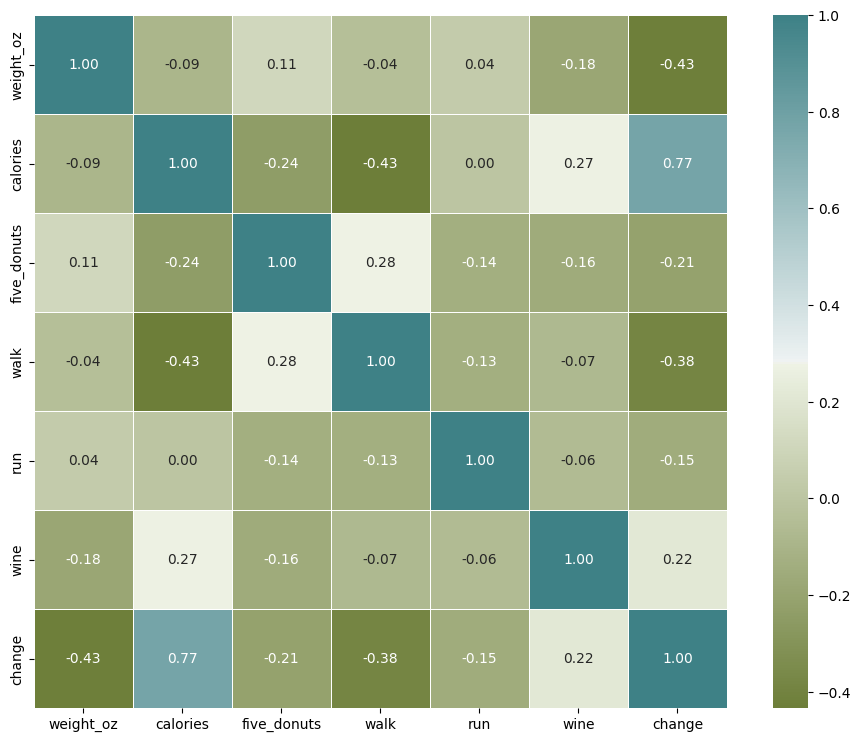

In [85]:
import seaborn as sns

plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [ ]:
# не совсем понятно, что такое weight и prot - может быть, тренировки? - вероятно, связаны, но не рискую удалять
# итак, в основном на таргет влияют признаки calories, weight_oz и walk. сначала попробуем ничего не удалять

In [171]:
# линейная регрессия без масштабирования
X = data.drop('change', axis=1)

y = data['change']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

model = LinearRegression()
model.fit(Xtrain, ytrain)
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

print('Scores:', r2_score(ytrain, pred_train), r2_score(ytest, pred_test), mean_squared_error(pred_test, ytest) ** 0.5, mean_squared_error(pred_train, ytrain) ** 0.5)
# модель страшно переобучается - неудивительно, записей немного
# без weight и prot чуть лучше

Scores: 0.8033994062413096 0.49182806599357043 16.364084905543827 11.141595806280511


In [90]:
pred_train

array([-23.26990391, -14.24125975,  18.26843047, -13.32078404,
       -46.98724144, -34.26421361,  24.49700492,  21.95379417,
        18.03850245, -16.28054235, -13.50104909,  14.76457647,
        31.81549216,  25.97783445,   9.2711576 ,  55.87124942,
        34.39568369, -10.2116565 , -11.15095412,  -3.21034506,
        40.2522326 ,  89.69794982,   1.96294463, -16.90717452,
        17.50187942,   8.6785305 ,   8.83498653,  -0.83988088,
        25.6967189 ,  18.32390319,   2.42377082,  28.66018596,
        32.26486741,  -8.5214754 , -20.09650812,   0.31816407,
       -29.77586283, -11.96288295, -45.54808094,  -0.246878  ,
        -1.23959315,   7.50497313, -11.22399516, -23.36572279,
        -7.35014804,  -8.95140577,  -8.32234263,  25.62778515,
        23.12005749, -13.65812809, -25.83756883,  12.46998736,
        30.90696632, -24.42178639,  -2.01270974,  39.32170704,
        -0.61870259, -25.75503236, -29.56144722, -11.02413902,
       -21.01881531,  -1.24593425,  36.34866632,   4.48

In [88]:
ytrain

,change
92,-32.0
23,-26.0
80,26.0
8,-8.0
68,-38.0
...,...
69,-12.0
19,14.0
89,-16.0
111,34.0


In [ ]:
# модель как минимум не ошибается со знаком. и истинные значения не сильно отличаются от предсказанных

In [172]:
# линейная регрессия с масштабированием
scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred_train), r2_score(ytest, ypred_test), mean_squared_error(ypred_test, ytest) ** 0.5, mean_squared_error(ypred_train, ytrain) ** 0.5)

Scores: 0.8033994062413096 0.49182806599356954 16.36408490554384 11.141595806280511


In [173]:
# оптимизируем параметр а
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas,
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [174]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred3_train = regressor2.predict(Xtrain)
ypred3_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred3_train), r2_score(ytest, ypred3_test), mean_squared_error(ypred3_test, ytest) ** 0.5, mean_squared_error(ypred3_train, ytrain) ** 0.5)
# значения теста чуть подтянулись

Scores: 0.8027659752958688 0.5007896185913234 16.219153741077108 11.159530024976712


In [175]:
# L2 сразу с поиском а по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(-2, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas,
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e-02, 1.09698580e-02, 1.20337784e-02, 1.32008840e-02,
       1.44811823e-02, 1.58856513e-02, 1.74263339e-02, 1.91164408e-02,
       2.09704640e-02, 2.30043012e-02, 2.52353917e-02, 2.76828663e-02,
       3.03677112e-02, 3.33129479e-02, 3.65438307e-02, 4.00880633e-02,
       4.39760361e-02, 4.82410870e-02, 5.29197874e-02, 5.80522552e-02,
       6.36824994e-02, 6.98587975e-0...
       1.18953407e+05, 1.30490198e+05, 1.43145894e+05, 1.57029012e+05,
       1.72258597e+05, 1.88965234e+05, 2.07292178e+05, 2.27396575e+05,
       2.49450814e+05, 2.73644000e+05, 3.00183581e+05, 3.29297126e+05,
       3.61234270e+05, 3.96268864e+05, 4.34701316e+05, 4.76861170e+05,
       5.23109931e+05, 5.73844165e+05, 6.29498899e+05, 6.90551352e+05,
       7.57525026e+05, 8.30994195e+05, 9.11588830e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [176]:
regressor3 = Ridge(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred4_train = regressor3.predict(Xtrain)
ypred4_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred4_train), r2_score(ytest, ypred4_test), mean_squared_error(ypred4_test, ytest) ** 0.5, mean_squared_error(ypred4_train, ytrain) ** 0.5)
# опять-таки, чуть хуже L1

Scores: 0.8022509218530915 0.492679654413276 16.35036778797995 11.174091424469605


In [177]:
# и одновременно 2 регуляризации
from sklearn.linear_model import ElasticNet

regressor4 = ElasticNet(alpha = 0.5, l1_ratio = 0.5)

regressor4.fit(Xtrain, ytrain)
ypred5_train = regressor4.predict(Xtrain)
ypred5_test = regressor4.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred5_train), r2_score(ytest, ypred5_test), mean_squared_error(ypred5_test, ytest) ** 0.5, mean_squared_error(ypred5_train, ytrain) ** 0.5)

Scores: 0.7699500349481516 0.47884974953363524 16.571730495851373 12.05219285171234


Лучший показатель на L1 регуляризации - действительно, модель сильно переобучается, и регуляризация помогает выровнять веса при малом объеме данных

# Задание 3.

Поработайте с датасетом Life Expectancy. Целевая колонка - Life Expectancy, собственно.

In [178]:
data = pd.read_csv('Life Expectancy Data.csv')
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [121]:
data[data['Life expectancy'].isna()]

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
624,Cook Islands,2013,Developing,NaN,NaN,0,0.01,0.000000,98.0,0,...,98.0,3.58,98.0,0.1,NaN,NaN,0.1,0.1,NaN,NaN
769,Dominica,2013,Developing,NaN,NaN,0,0.01,11.419555,96.0,0,...,96.0,5.58,96.0,0.1,722.756650,NaN,2.7,2.6,0.721,12.7
1650,Marshall Islands,2013,Developing,NaN,NaN,0,0.01,871.878317,8.0,0,...,79.0,17.24,79.0,0.1,3617.752354,NaN,0.1,0.1,NaN,0.0
1715,Monaco,2013,Developing,NaN,NaN,0,0.01,0.000000,99.0,0,...,99.0,4.30,99.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN
1812,Nauru,2013,Developing,NaN,NaN,0,0.01,15.606596,87.0,0,...,87.0,4.65,87.0,0.1,136.183210,NaN,0.1,0.1,NaN,9.6
1909,Niue,2013,Developing,NaN,NaN,0,0.01,0.000000,99.0,0,...,99.0,7.20,99.0,0.1,NaN,NaN,0.1,0.1,NaN,NaN
1958,Palau,2013,Developing,NaN,NaN,0,NaN,344.690631,99.0,0,...,99.0,9.27,99.0,0.1,1932.122370,292.0,0.1,0.1,0.779,14.2
2167,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.54,0.000000,97.0,0,...,96.0,6.14,96.0,0.1,NaN,NaN,3.7,3.6,0.749,13.4
2216,San Marino,2013,Developing,NaN,NaN,0,0.01,0.000000,69.0,0,...,69.0,6.50,69.0,0.1,NaN,NaN,NaN,NaN,NaN,15.1
2713,Tuvalu,2013,Developing,NaN,NaN,0,0.01,78.281203,9.0,0,...,9.0,16.61,9.0,0.1,3542.135890,1819.0,0.2,0.1,NaN,0.0


In [126]:
data[data['Country'] == 'Cook Islands']

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
624,Cook Islands,2013,Developing,NaN,NaN,0,0.01,0.0,98.0,0,...,98.0,3.58,98.0,0.1,NaN,NaN,0.1,0.1,NaN,NaN


In [135]:
data['Status'].unique()

array(['Developing', 'Developed'], dtype=object)

In [ ]:
# на первый взгляд кажется, что выбросов нет. но нужно обработать пропущенные значения. просто 0 подставить не получится.
# была идея подставить значения для той же страны, но другого года, - однако не для всех стран есть статистика за несколько лет
# тогда лучше подставить средние значения

In [179]:
columns_list = data.columns.tolist()
columns_list = [col for col in columns_list if col not in ['Country', 'Year', 'Status']]

In [180]:
for element in columns_list:
  data[element] = data[element].fillna(data[element].mean())

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [181]:
# что делать со столбцом "Страны"? с одной стороны, страна - важный признак, отражающий многие факторы. с другой стороны, он наверняка кореллирует с другими
# поскольку значения этого столбца мы можем только заванхотить, и есть риск корелляции, думаю, стоит убрать этот признак
# то же самое с годом. он наверняка кореллирует с другими признаками и его лучше заванхотить. но поскольку признаков и без того много, лучше не рисковать
# Status можно попробовать заванхотить и посмотреть, будет ли корреляция с другими признаками
data.drop(['Country', 'Year'], axis=1, inplace=True)
data = pd.get_dummies(data, columns=['Status'], drop_first=True)

<Axes: >

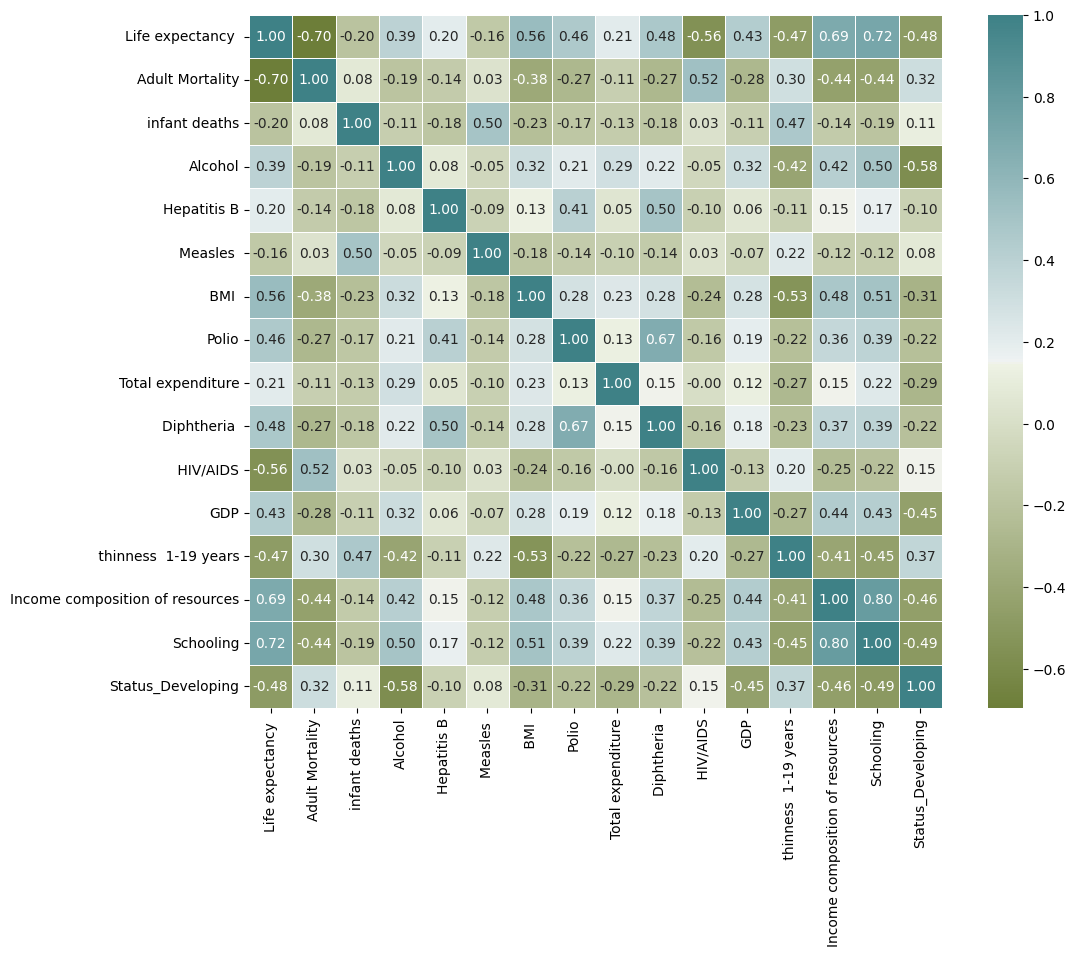

In [150]:
import seaborn as sns

plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [182]:
# есть много взаимосвязанных признаков. можно попробовать их убрать
data.drop(['percentage expenditure', 'under-five deaths ', ' thinness 5-9 years'], axis=1, inplace=True)

In [183]:
# и только один откровенно бесполезный признак
data.drop(['Population'], axis=1, inplace=True)

In [184]:
# линейная регрессия без масштабирования
X = data.drop('Life expectancy ', axis=1)

y = data['Life expectancy ']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

model = LinearRegression()
model.fit(Xtrain, ytrain)
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

print('Scores:', r2_score(ytrain, pred_train), r2_score(ytest, pred_test), mean_squared_error(pred_test, ytest) ** 0.5, mean_squared_error(pred_train, ytrain) ** 0.5)
# модель показала отличный результат и совсем небольшую ошибку. пытаемся улучшить

Scores: 0.8058487321823291 0.8268494855569558 3.882480068035299 4.20770402835017


In [185]:
# линейная регрессия с масштабированием
scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred_train), r2_score(ytest, ypred_test), mean_squared_error(ypred_test, ytest) ** 0.5, mean_squared_error(ypred_train, ytrain) ** 0.5)
# масштабирование, как и на датасетах выше, не изменило результат

Scores: 0.8058487321823291 0.8268494855569555 3.8824800680353038 4.20770402835017


In [186]:
# оптимизируем параметр а
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas,
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [187]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred3_train = regressor2.predict(Xtrain)
ypred3_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred3_train), r2_score(ytest, ypred3_test), mean_squared_error(ypred3_test, ytest) ** 0.5, mean_squared_error(ypred3_train, ytrain) ** 0.5)
# значения улучшились незначительно

Scores: 0.8050745365464798 0.8275634815238395 3.874466985520293 4.216084980768437


In [188]:
# L2 сразу с поиском а по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(-2, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas,
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e-02, 1.09698580e-02, 1.20337784e-02, 1.32008840e-02,
       1.44811823e-02, 1.58856513e-02, 1.74263339e-02, 1.91164408e-02,
       2.09704640e-02, 2.30043012e-02, 2.52353917e-02, 2.76828663e-02,
       3.03677112e-02, 3.33129479e-02, 3.65438307e-02, 4.00880633e-02,
       4.39760361e-02, 4.82410870e-02, 5.29197874e-02, 5.80522552e-02,
       6.36824994e-02, 6.98587975e-0...
       1.18953407e+05, 1.30490198e+05, 1.43145894e+05, 1.57029012e+05,
       1.72258597e+05, 1.88965234e+05, 2.07292178e+05, 2.27396575e+05,
       2.49450814e+05, 2.73644000e+05, 3.00183581e+05, 3.29297126e+05,
       3.61234270e+05, 3.96268864e+05, 4.34701316e+05, 4.76861170e+05,
       5.23109931e+05, 5.73844165e+05, 6.29498899e+05, 6.90551352e+05,
       7.57525026e+05, 8.30994195e+05, 9.11588830e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [189]:
regressor3 = Ridge(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred4_train = regressor3.predict(Xtrain)
ypred4_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred4_train), r2_score(ytest, ypred4_test), mean_squared_error(ypred4_test, ytest) ** 0.5, mean_squared_error(ypred4_train, ytrain) ** 0.5)
# 3й тест и все тот же результат - L1 незначительно превосходит L2

Scores: 0.8058460126728293 0.8269185790531762 3.8817053637586367 4.207733497256387


In [190]:
# и одновременно 2 регуляризации
from sklearn.linear_model import ElasticNet

regressor4 = ElasticNet(alpha = 0.5, l1_ratio = 0.5)

regressor4.fit(Xtrain, ytrain)
ypred5_train = regressor4.predict(Xtrain)
ypred5_test = regressor4.predict(Xtest)

print('Scores:', r2_score(ytrain, ypred5_train), r2_score(ytest, ypred5_test), mean_squared_error(ypred5_test, ytest) ** 0.5, mean_squared_error(ypred5_train, ytrain) ** 0.5)

Scores: 0.7930319526085201 0.8178198988269285 3.9824268851455065 4.344369134913163


Итого - L1 дает лучший результат с совсем небольшим преимуществом (я бы даже сказала совсем незначительным).